# A Linear Soft Sensor for Membrane Fouling — Seawater RO Desalination

A **soft sensor** is a model that stands in for a measurement you don't have.
It can be used to stand in for missing measurements or provide a virtual point of comparison
to identify faults. 

In this notebook we learn the expected performance of a clean membrane based on feed conditions and
watch for when the membrane performance degrades due to fowling.

This uses one plant's operating history simulated in WaterTAP — `seawater-ro-fouled` — spanning two
regimes back to back:

1. A **clean baseline**: the first month of operation (e.g. right after
   commissioning or the last documented cleaning).
2. A **fouling event**: permeability then declines on a slow exponential
   trajectory as a cake layer / biofilm builds up (see
   `deployments/WATERTAP/models/seawater-ro-fouled/generate-values.py`).

We train a linear regression on the clean baseline only, to predict **permeate flow** and **salt passage** from **feed
flow, pressure, temperature and TDS**. 

## Setup
0. Follow the steps in [deployments/WATERTAP/README.md](../../deployments/WATERTAP/README.md) to install requirements.
1. Start the server:

   `acquirium server --config deployments/WATERTAP/models/seawater-ro-fouled/acquirium.toml`
2. Connect:

In [1]:
from datetime import timedelta

from acquirium import Acquirium
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

acq = Acquirium(server_url="localhost", server_port=8000, use_ssl=False)
S223 = "http://data.ashrae.org/standard223#"
NAWI = "urn:nawi-water-ontology#"

pl.Config.set_tbl_width_chars(1000)
pl.Config.set_fmt_str_lengths(200)

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
BLUE = "#2a78d6"
CRITICAL = "#d03b3b"

## Pulling feed and permeate data — by meaning

We can interrogate our data using acquirium to find our features and target variable

The RO unit (`wbsf:RO`, class `nawi:ReverseOsmosisMembrane`) has one inlet
`ConnectionPoint` carrying the seawater feed, and two outlets disambiguated by
medium. The permeate is `s223:Fluid-Water` and the retentate/concentrate is
`nawi:Water-Brine`. We walk `RO -> hasConnectionPoint -> (filter by hasMedium) ->
hasProperty` to land on the sensors we want (rather than hard-coding point names). 
This means we don't have to remember the exact names of the model, and the 
same query shape would work against another similar plant using Acquirium.

In [ ]:
acq.find_entity(uri = "wbsf:RO").find_all_data()

Query(client=<acquirium.Client.client.AcquiriumClient object at 0x364795550>, query_graph=QueryGraph(nodes={0: QueryNode(id=0, rdf_class=None, alias=None, constraints={'instance_uri': 'urn:swro-fouled/RO'}), 2: QueryNode(id=2, rdf_class=None, alias='0_data', constraints={'is_data_node': True, 'path_from': None})}, edges=[QueryEdge(source_id=0, target_id=2, hops=1, predicates=None, direction=None, cp_filter=None)], aliases={'0': 0, '0_data': 2}, aliases_reverse={0: '0', 2: '0_data'}, current_pointer=2, data_nodes={2: DataNodeInfo(node_id=2, filters={})}), _next_id=5, cache={})

In [ ]:
help(acq.find_all_data)

Help on method find_all_data in module acquirium.Client.acquirium:

find_all_data(*, _class: 'Optional[str]' = None, uri: 'str | URIRef | None' = None) -> "'Query'" method of acquirium.Client.acquirium.Acquirium instance



In [5]:
def ro_stream_query(ro_uri: str, medium: str, alias: str):
    """Data observed at the RO unit's connection point carrying `medium`."""
    return (
        acq.find_entity(uri=ro_uri, alias="ro")
           .find_related(_class="ConnectionPoint", alias=f"{alias}_cp",
                         predicates=[S223 + "hasConnectionPoint"], hops=1)
           .find_related(uri=medium, alias=f"{alias}_medium", _from=f"{alias}_cp",
                         predicates=[S223 + "hasMedium"], hops=1)
           .find_data(alias=alias, _from=f"{alias}_cp")
    )

# get our data sources for feed and permeate
def build_dataset(ro_uri: str) -> pl.DataFrame:
    """Join feed + permeate streams for one RO unit into one wide frame."""
    feed_df = ro_stream_query(ro_uri, NAWI + "Water-Seawater", "feed").dataframe(shape="wide", cast_value="float")
    permeate_df = ro_stream_query(ro_uri, S223 + "Fluid-Water", "permeate").dataframe(shape="wide", cast_value="float")

    df = feed_df.join(permeate_df, on="time", how="inner")

    return df.drop_nulls().sort("time")

In [6]:
df = build_dataset("wbsf:RO")
print(f"{df.shape[0]} samples, {df['time'].min()} .. {df['time'].max()}")
print('Retrieved Columns:', df.columns)
df.columns

1440 samples, 2025-01-01 00:00:00+00:00 .. 2025-03-01 23:00:00+00:00
Retrieved Columns: ['time', 'feed__wbsf:RO-in-flow-mass-water', 'feed__wbsf:RO-in-temperature', 'feed__wbsf:RO-in-flow-mass-tds', 'feed__wbsf:RO-in-pressure', 'permeate__wbsf:RO-out-pressure', 'permeate__wbsf:RO-out-flow-mass-tds', 'permeate__wbsf:RO-out-flow-mass-water']


['time',
 'feed__wbsf:RO-in-flow-mass-water',
 'feed__wbsf:RO-in-temperature',
 'feed__wbsf:RO-in-flow-mass-tds',
 'feed__wbsf:RO-in-pressure',
 'permeate__wbsf:RO-out-pressure',
 'permeate__wbsf:RO-out-flow-mass-tds',
 'permeate__wbsf:RO-out-flow-mass-water']

## Split by time

Everything above is one continuous series from one plant. We'll treat the plant's first two weeks of
operation as a known-clean baseline and train on that alone, then score the
trained model across the plant's entire history — clean baseline and fouling
event together — the way you'd actually deploy a soft sensor against a live
historian.

In [ ]:
BASELINE_DAYS = 14  # assumed known-clean window: the plant's first two weeks of operation
baseline_end = df["time"][0] + timedelta(days=BASELINE_DAYS)

baseline = df.filter(pl.col("time") < baseline_end)
print(f"baseline (training pool): {baseline.shape[0]} samples, "
      f"{baseline['time'].min()} .. {baseline['time'].max()}")
print(f"full history (scored):    {df.shape[0]} samples, "
      f"{df['time'].min()} .. {df['time'].max()}")

baseline (training pool): 336 samples, 2025-01-01 00:00:00+00:00 .. 2025-01-14 23:00:00+00:00
full history (scored):    1440 samples, 2025-01-01 00:00:00+00:00 .. 2025-03-01 23:00:00+00:00


## The model: OLS (with optional pairwise interaction terms)

We can use a linear model to predict what the permeate should be for our clean membrane

In [ ]:
# I can use my alias assigned earlier to get my feed columns as features
FEATURES = [c for c in df.columns if "feed" in c]
PREDICTION_TARGET = "permeate__wbsf:RO-out-flow-mass-water"

class InteractionOLS:
    """OLS on standardized features, optionally with all pairwise interaction terms."""

    def __init__(self, features):
        self.features = features

    def _design(self, X):
        Xs = (X - self.mean_) / self.std_
        cols = [np.ones(len(Xs))] + [Xs[:, i] for i in range(Xs.shape[1])]
        return np.column_stack(cols)

    def fit(self, X, y):
        self.mean_ = X.mean(axis=0)
        std = X.std(axis=0)
        self.std_ = np.where(std == 0, 1.0, std)  # constant feature -> zero column, not NaN
        D = self._design(X)
        self.coef_, *_ = np.linalg.lstsq(D, y, rcond=None)
        resid = y - D @ self.coef_
        self.train_resid_std_ = resid.std()
        ss_res, ss_tot = (resid ** 2).sum(), ((y - y.mean()) ** 2).sum()
        self.r2_ = 1 - ss_res / ss_tot
        return self

    def predict(self, X):
        return self._design(X) @ self.coef_

## Train on the clean baseline only

A random 80/20 split of the baseline window.

In [ ]:
rng = np.random.RandomState(0)
n = baseline.shape[0]
idx = rng.permutation(n)
split = int(n * 0.8)
train_idx, test_idx = idx[:split], idx[split:]

X_baseline = baseline.select(FEATURES).to_numpy()
y_flow = baseline[PREDICTION_TARGET].to_numpy()

model_flow = InteractionOLS(FEATURES).fit(X_baseline[train_idx], y_flow[train_idx])


def r2(y_true, y_pred):
    return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()


print("permeate flow   -- train R2: %.5f   held-out R2: %.5f   train residual std: %.4f kg/s"
      % (model_flow.r2_, r2(y_flow[test_idx], model_flow.predict(X_baseline[test_idx])), model_flow.train_resid_std_))

permeate flow   -- train R2: 0.99054   held-out R2: 0.99146   train residual std: 0.3502 kg/s


## Which inputs actually matter?

Because every term was standardized before fitting (zero mean, unit variance,
using training statistics), the coefficients are already on a comparable
footing: each one is the expected change in the target, in its natural units,
per **one standard deviation** move in that term — no separate permutation- or
SHAP-importance step needed, the coefficients themselves are the importances for
a model built this way.

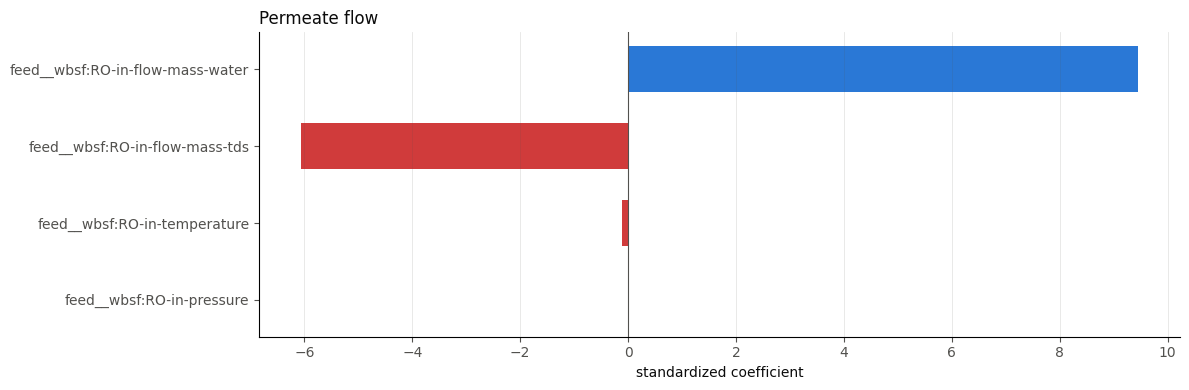

In [ ]:
def plot_importance(ax, model, title):
    coefs = model.coef_[1:]  # drop the intercept -- not a "feature"
    order = np.argsort(np.abs(coefs))
    ax.barh([FEATURES[i] for i in order], coefs[order],
            color=[BLUE if v >= 0 else CRITICAL for v in coefs[order]], height=0.6)
    ax.axvline(0, color=INK_SECONDARY, linewidth=0.8)
    ax.set_title(title, color=INK_PRIMARY, loc="left")
    ax.set_xlabel("standardized coefficient", color=INK_PRIMARY)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK_SECONDARY)
    ax.grid(True, axis="x", color=INK_SECONDARY, alpha=0.15, linewidth=0.6)


fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))
plot_importance(ax1, model_flow, "Permeate flow")
fig.tight_layout()
plt.show()

`feed_pressure` is constant in this dataset, so there is no measurable relationship.
 Otherwise `feed_flow` and `feed_tds` dominate both targets. More feed flow raises flow but lowers salt passage; more feed
TDS does the reverse, which matches how we expect an RO membrane to behave. 

## Estimating permeability across the plant's entire history

We feed the *whole* time series — baseline and fouling event together — through
`model_flow`. It never sees anything past the first two weeks during training, 
so its prediction at every point is "expected flux if the membrane were still at baseline." 
The ratio of actual to predicted flow (**relative permeability**) should be ≈1.0 while the
membrane is clean, dropping as it fouls. We smooth it with a short rolling mean.

In [ ]:
X_all = df.select(FEATURES).to_numpy()

pred_flow = model_flow.predict(X_all)

relative_permeability_raw = df[PREDICTION_TARGET].to_numpy() / pred_flow

SMOOTH_SAMPLES = 6  
relative_permeability = (
    pl.Series(relative_permeability_raw)
      .rolling_mean(window_size=SMOOTH_SAMPLES, min_samples=1)
      .to_numpy()
)

# add predicted cols
df = df.with_columns([
    pl.Series("predicted_permeate_flow", pred_flow),
    pl.Series("relative_permeability_raw", relative_permeability_raw),
    pl.Series("relative_permeability", relative_permeability),
])
df.select(["time", PREDICTION_TARGET, "predicted_permeate_flow", "relative_permeability"]).head(3)

time,permeate__wbsf:RO-out-flow-mass-water,predicted_permeate_flow,relative_permeability
"datetime[μs, UTC]",f64,f64,f64
2025-01-01 00:00:00 UTC,138.968712,138.657917,1.002241
2025-01-01 01:00:00 UTC,135.245735,135.280037,1.000994
2025-01-01 02:00:00 UTC,133.821564,134.103139,0.999963


## Detecting the onset

To detect the fouling, we use a sustained-exceedance rule. 
If a relative-permeability estimate exceeds a **4σ band around the
baseline's own noise for 4 consecutive hourly samples** we call it an anomoly.

In [ ]:
K_SIGMA = 4.0
SUSTAIN_SAMPLES = 4  # 4 consecutive hourly samples

baseline_rel_perm = relative_permeability[: baseline.shape[0]]
baseline_mean = baseline_rel_perm.mean()
baseline_std = baseline_rel_perm.std()
threshold = baseline_mean - K_SIGMA * baseline_std

below = relative_permeability < threshold
sustained = np.convolve(below.astype(int), np.ones(SUSTAIN_SAMPLES, dtype=int), mode="valid") == SUSTAIN_SAMPLES
onset_idx = int(np.argmax(sustained)) if sustained.any() else None

print(f"baseline relative permeability: {baseline_mean:.4f} +/- {baseline_std:.4f}   (threshold: {threshold:.4f})")
if onset_idx is not None:
    onset_time = df["time"][onset_idx]
    elapsed = onset_time - df["time"][0]
    print(f"Sustained drop detected at {onset_time}  ({elapsed} into the run)")
    print(f"relative permeability at onset: {relative_permeability[onset_idx]:.3f}   "
          f"(vs. {relative_permeability[-24:].mean():.3f} by the end of the run)")
else:
    print("No sustained drop detected.")

baseline relative permeability: 1.0001 +/- 0.0010   (threshold: 0.9961)
Sustained drop detected at 2025-02-01 00:00:00+00:00  (31 days, 0:00:00 into the run)
relative permeability at onset: 0.996   (vs. 0.851 by the end of the run)


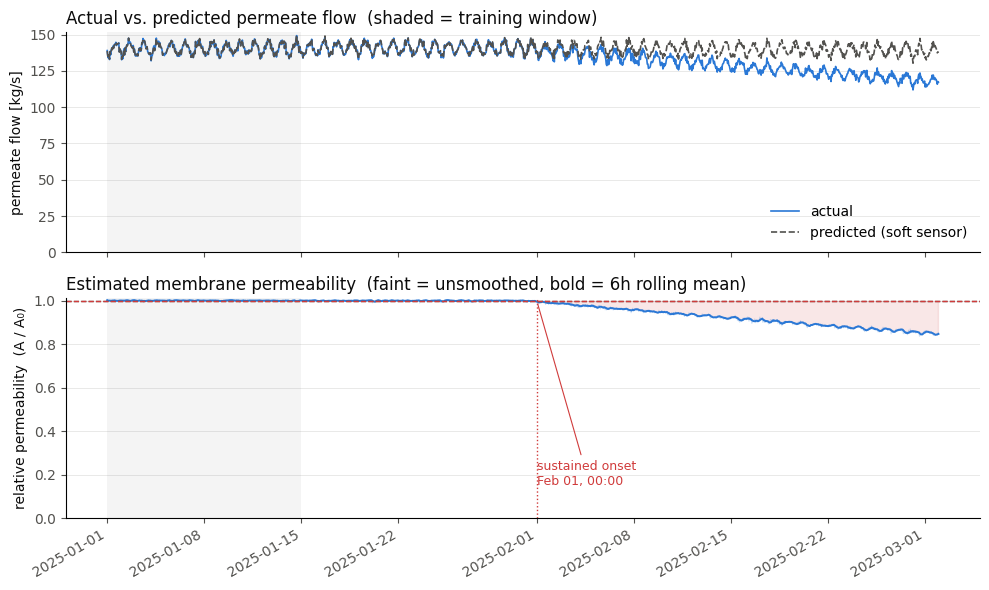

In [ ]:
fig, (ax_flow, ax_perm) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

t = df["time"].to_list()

for ax in (ax_flow, ax_perm):
    ax.axvspan(t[0], baseline_end, color=INK_SECONDARY, alpha=0.06, linewidth=0)

ax_flow.plot(t, df[PREDICTION_TARGET], color=BLUE, linewidth=1.2, label="actual")
ax_flow.plot(t, df["predicted_permeate_flow"], color=INK_SECONDARY, linewidth=1.2,
             linestyle="--", label="predicted (soft sensor)")
ax_flow.set_ylabel("permeate flow [kg/s]", color=INK_PRIMARY)
ax_flow.legend(frameon=False)
ax_flow.set_title("Actual vs. predicted permeate flow  (shaded = training window)",
                   color=INK_PRIMARY, loc="left")

ax_perm.plot(t, relative_permeability_raw, color=BLUE, linewidth=0.6, alpha=0.25)
ax_perm.plot(t, relative_permeability, color=BLUE, linewidth=1.4)
ax_perm.axhline(1.0, color=INK_SECONDARY, linewidth=1, linestyle="--")
ax_perm.axhline(threshold, color=CRITICAL, linewidth=1, linestyle="--")
ax_perm.fill_between(t, threshold, relative_permeability, where=(relative_permeability < threshold),
                      color=CRITICAL, alpha=0.12, interpolate=True)
ax_flow.set_ylim(0)
ax_perm.set_ylim(0)
if onset_idx is not None:
    ax_perm.axvline(t[onset_idx], color=CRITICAL, linewidth=1, linestyle=":")
    ax_perm.annotate(f"sustained onset\n{onset_time:%b %d, %H:%M}",
                      xy=(t[onset_idx], threshold), xycoords="data",
                      xytext=(t[onset_idx], 0.15), textcoords=("data", "axes fraction"),
                      color=CRITICAL, fontsize=9,
                      arrowprops=dict(arrowstyle="-", color=CRITICAL, linewidth=0.8))
ax_perm.set_ylabel("relative permeability  (A / A₀)", color=INK_PRIMARY)
ax_perm.set_title("Estimated membrane permeability  (faint = unsmoothed, bold = 6h rolling mean)",
                   color=INK_PRIMARY, loc="left")

for ax in (ax_flow, ax_perm):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color=INK_SECONDARY, alpha=0.15, linewidth=0.6)
    ax.tick_params(colors=INK_SECONDARY)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Fault detection using our linear regression soft sensor allows us to detect exactly when fouling occurs, several days before degredation is obvious